In [21]:
import torch as t
import torch.nn as nn
score = t.Tensor([[1, 2, 3, 5], [1,2, 3, 3], [1,2,3,3]])
print(score)
print(score.type)
print(score.shape)
label = t.Tensor([1, 2, 1]).long() # 会把target变成ont-hot形式
print(label)
print(label.type)
print(label.shape)
criterion = nn.CrossEntropyLoss()
loss = criterion(score, label)
print(loss)

tensor([[1., 2., 3., 5.],
        [1., 2., 3., 3.],
        [1., 2., 3., 3.]])
<built-in method type of Tensor object at 0x12efaec60>
torch.Size([3, 4])
tensor([1, 2, 1])
<built-in method type of Tensor object at 0x12e4cab40>
torch.Size([3])
tensor(2.0068)


0         1         2         3         4         5         6
0  1.000000  0.459148  0.459148  0.459148  0.459148  0.459148  0.459148
1  0.459148  1.000000  0.459148  0.459148  0.459148  0.459148  0.459148
2  0.459148  0.459148  1.000000  0.190875  0.190875  0.459148  0.190875
3  0.459148  0.459148  0.190875  1.000000  0.459148  0.459148  0.459148
4  0.459148  0.459148  0.190875  0.459148  1.000000  0.459148  0.459148
5  0.459148  0.459148  0.459148  0.459148  0.459148  1.000000  0.190875
6  0.459148  0.459148  0.190875  0.459148  0.459148  0.190875  1.000000


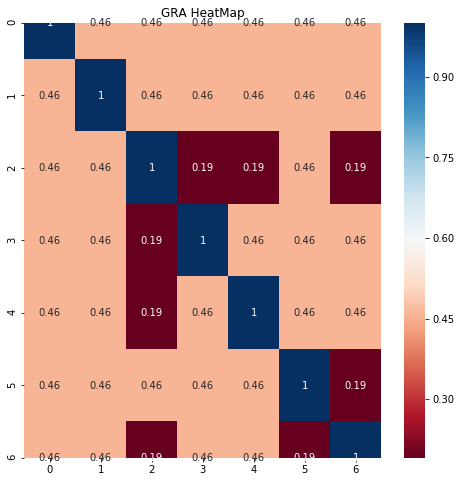

In [25]:
import pandas as pd
import numpy as np
from minepy import MINE
import seaborn as sns
import matplotlib.pyplot as plt

wine = np.random.rand(6, 7) # 特征数，样本数
 
def MIC_matirx(dataframe, mine):
    data = np.array(dataframe)
    n = len(data[0, :])
    result = np.zeros([n, n])
 
    for i in range(n):
        for j in range(n):
            mine.compute_score(data[:, i], data[:, j])
            result[i, j] = mine.mic()
            result[j, i] = mine.mic()
    RT = pd.DataFrame(result)
    return RT
 
def ShowHeatMap(DataFrame):
    colormap = plt.cm.RdBu
    ylabels = DataFrame.columns.values.tolist()
    f, ax = plt.subplots(figsize=(8, 8))
    ax.set_title('GRA HeatMap')
    sns.heatmap(DataFrame.astype(float),
                cmap=colormap,
                ax=ax,
                annot=True,
                yticklabels=ylabels,
                xticklabels=ylabels)
    plt.show()
 
mine = MINE(alpha=0.6, c=15)
data_wine_mic = MIC_matirx(wine, mine)
print(data_wine_mic)
ShowHeatMap(data_wine_mic)

In [ ]:
# DataLoader